## **GetAround Deployment Project — Jedha Bootcamp**

## **01. Delay Analysis: EDA, KPIs & Dashboard**

### **Objectif**

Le Product Manager veut savoir s'il faut implémenter un **délai minimum entre deux locations consécutives** sur un même véhicule. Ce notebook explore les données de retards, quantifie le problème, simule l'impact de différents seuils, et formule une recommandation data-driven.

**Questions du PM :**
1. Quelle part des locations est impactée par les retours en retard ?
2. Quel seuil choisir ? Quel scope (tous les véhicules vs Connect only) ?
3. Quel est le trade-off entre problèmes résolus et revenus perdus ?
4. Comment le déployer de façon progressive ?

### **1. Setup & chargement des données**

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Style
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)

# Path 
delay_analysis_data = '../data/get_around_delay_analysis.xlsx'

In [24]:
df = pd.read_excel(delay_analysis_data)
df.head()

,rental_id,car_id,checkin_type,state,delay_at_checkout_in_minutes,previous_ended_rental_id,time_delta_with_previous_rental_in_minutes
0,505000,363965,mobile,canceled,NaN,NaN,NaN
1,507750,269550,mobile,ended,-81.00,NaN,NaN
2,508131,359049,connect,ended,70.00,NaN,NaN
3,508865,299063,connect,canceled,NaN,NaN,NaN
4,511440,313932,mobile,ended,NaN,NaN,NaN


### **2. Exploration des données** 

In [3]:
print('Type de données :', df.dtypes)
print('\nNombre de lignes et de colonnes :', df.shape)
print('\nNombre de valeurs manquantes par colonne :')
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
print(missing_pct)

Type de données : rental_id                                       int64
car_id                                          int64
checkin_type                                      str
state                                             str
delay_at_checkout_in_minutes                  float64
previous_ended_rental_id                      float64
time_delta_with_previous_rental_in_minutes    float64
dtype: object

Nombre de lignes et de colonnes : (21310, 7)

Nombre de valeurs manquantes par colonne :
rental_id                                     0.00
car_id                                        0.00
checkin_type                                  0.00
state                                         0.00
delay_at_checkout_in_minutes                 23.30
previous_ended_rental_id                     91.40
time_delta_with_previous_rental_in_minutes   91.40
dtype: float64


In [4]:
print("Canceled avec delay NaN:", df[df['state']=='canceled']['delay_at_checkout_in_minutes'].isna().sum(),
      f"/ {(df['state']=='canceled').sum()} canceled total")

print("Ended avec delay NaN:   ", df[df['state']=='ended']['delay_at_checkout_in_minutes'].isna().sum(),
      f"/ {(df['state']=='ended').sum()} ended total")

print("\n=> Les canceled n'ont logiquement pas de checkout => delay NaN est attendu")
print("=> 1700 ended sans delay = données non enregistrées (9.4% des ended)")

Canceled avec delay NaN: 3264 / 3265 canceled total
Ended avec delay NaN:    1700 / 18045 ended total

=> Les canceled n'ont logiquement pas de checkout => delay NaN est attendu
=> 1700 ended sans delay = données non enregistrées (9.4% des ended)


In [5]:
# Stats descriptives complètes
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
rental_id,21310.00,NaN,NaN,NaN,549712.88,13863.45,504806.00,540613.25,550350.00,560468.50,576401.00
car_id,21310.00,NaN,NaN,NaN,350030.60,58206.25,159250.00,317639.00,368717.00,394928.00,417675.00
checkin_type,21310,2,mobile,17003,NaN,NaN,NaN,NaN,NaN,NaN,NaN
state,21310,2,ended,18045,NaN,NaN,NaN,NaN,NaN,NaN,NaN
delay_at_checkout_in_minutes,16346.00,NaN,NaN,NaN,59.70,1002.56,-22433.00,-36.00,9.00,67.00,71084.00
previous_ended_rental_id,1841.00,NaN,NaN,NaN,550127.41,13184.02,505628.00,540896.00,550567.00,560823.00,575053.00
time_delta_with_previous_rental_in_minutes,1841.00,NaN,NaN,NaN,279.29,254.59,0.00,60.00,180.00,540.00,720.00


### **3. Exploration (EDA) - Vue d'ensemble**

#### **3.1 Distribution des variables catégorielles**

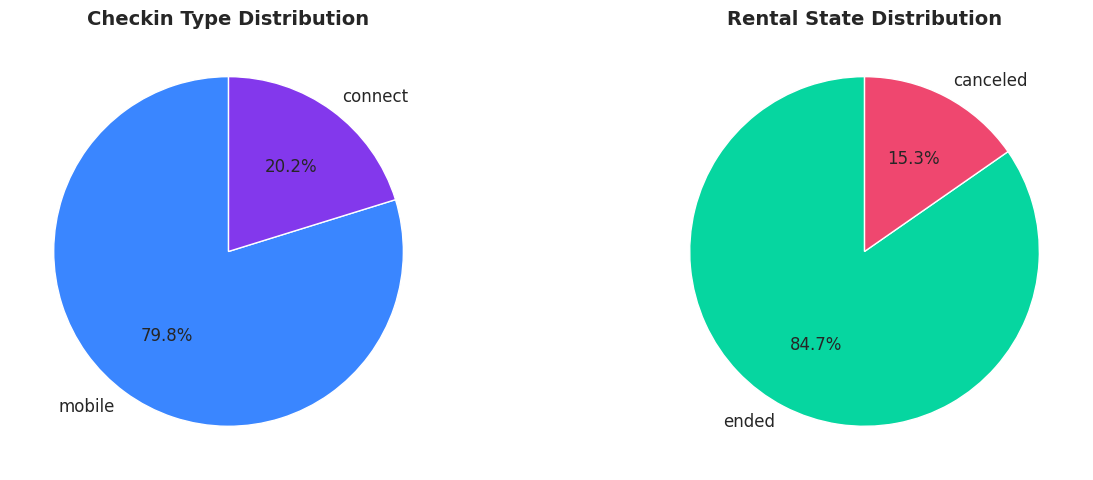

Mobile:   17,003 (79.8%)
Connect:   4,307 (20.2%)
Ended:    18,045 (84.7%)
Canceled:  3,265 (15.3%)


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Checkin type
checkin_counts = df['checkin_type'].value_counts()
colors = ['#3a86ff', '#8338ec']
axes[0].pie(checkin_counts.values, labels=checkin_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90, textprops={'fontsize': 12})
axes[0].set_title('Checkin Type Distribution', fontsize=14, fontweight='bold')

# State
state_counts = df['state'].value_counts()
colors2 = ['#06d6a0', '#ef476f']
axes[1].pie(state_counts.values, labels=state_counts.index, autopct='%1.1f%%',
            colors=colors2, startangle=90, textprops={'fontsize': 12})
axes[1].set_title('Rental State Distribution', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"Mobile:   {checkin_counts['mobile']:>6,} ({checkin_counts['mobile']/len(df)*100:.1f}%)")
print(f"Connect:  {checkin_counts['connect']:>6,} ({checkin_counts['connect']/len(df)*100:.1f}%)")
print(f"Ended:    {state_counts['ended']:>6,} ({state_counts['ended']/len(df)*100:.1f}%)")
print(f"Canceled: {state_counts['canceled']:>6,} ({state_counts['canceled']/len(df)*100:.1f}%)")

#### **3.2 Distribution des retards**

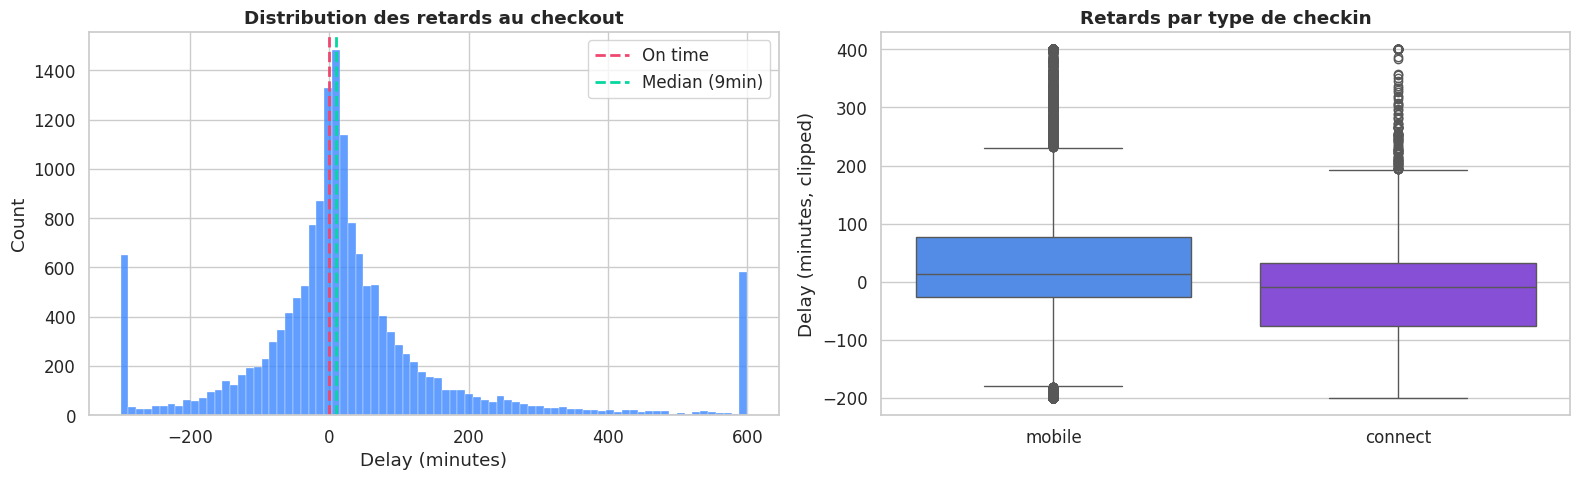

In [7]:
delay = df['delay_at_checkout_in_minutes'].dropna()

# Distribution des retards (clippée pour lisibilité)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Histogramme global
delay_clipped = delay.clip(-300, 600)
axes[0].hist(delay_clipped, bins=80, color='#3a86ff', alpha=0.8, edgecolor='white', linewidth=0.3)
axes[0].axvline(0, color='#ef476f', linestyle='--', linewidth=2, label='On time')
axes[0].axvline(delay.median(), color='#06d6a0', linestyle='--', linewidth=2, label=f'Median ({delay.median():.0f}min)')
axes[0].set_xlabel('Delay (minutes)')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution des retards au checkout', fontweight='bold')
axes[0].legend()

# Boxplot par checkin type
ended = df[df['state'] == 'ended'].copy()
ended['delay_clipped'] = ended['delay_at_checkout_in_minutes'].clip(-200, 400)
sns.boxplot(data=ended, x='checkin_type', y='delay_clipped', 
            palette=['#3a86ff', '#8338ec'], ax=axes[1])
axes[1].set_title('Retards par type de checkin', fontweight='bold')
axes[1].set_ylabel('Delay (minutes, clipped)')
axes[1].set_xlabel('')

plt.tight_layout()
plt.show()

In [8]:
# Breakdown par catégorie de retard
bins = [-np.inf, -60, 0, 30, 60, 120, 180, np.inf]
labels = ['Très en avance (<-1h)', 'En avance / à l\'heure', '0-30 min retard',
          '30-60 min', '1-2h retard', '2-3h retard', '3h+ retard']
delay_cat = pd.cut(delay, bins=bins, labels=labels)

cat_df = delay_cat.value_counts().reset_index()
cat_df.columns = ['Catégorie', 'Count']
cat_df['Pct'] = (cat_df['Count'] / cat_df['Count'].sum() * 100).round(1)

colors_bar = ['#06d6a0', '#43cea2', '#ffd166', '#f77f00', '#ef476f', '#d62828', '#9b2226']
fig = px.bar(cat_df, x='Catégorie', y='Count', color='Catégorie',
             color_discrete_sequence=colors_bar,
             title='Répartition des retards par catégorie',
             text='Pct')
fig.update_traces(texttemplate='%{text}%', textposition='outside')
fig.update_layout(showlegend=False, height=400)
fig.show()

#### **3.3 Analyse par checkin type**

> **Insight clé** : Les véhicules Connect représentent seulement 20% des locations mais 44% des consécutives.
> L'impact des retards est amplifié sur Connect car aucun contact humain n'est possible.

In [9]:
# Cross-tab checkin_type x state
ct = pd.crosstab(df['checkin_type'], df['state'], margins=True, normalize='index') * 100
print("Taux d'annulation par checkin type (%):")
print(ct.round(1))

print()

# Stats de retard par checkin type
for ct_type in ['mobile', 'connect']:
    sub = df[(df['checkin_type'] == ct_type) & (df['state'] == 'ended')]
    d = sub['delay_at_checkout_in_minutes'].dropna()
    print(f"{ct_type.upper():>8}: mean={d.mean():.1f}min, median={d.median():.0f}min, "
          f"late%={((d>0).mean()*100):.1f}%, very_late(>1h)={((d>60).mean()*100):.1f}%")

Taux d'annulation par checkin type (%):
state         canceled  ended
checkin_type                 
connect          18.50  81.50
mobile           14.50  85.50
All              15.30  84.70

  MOBILE: mean=88.2min, median=14min, late%=61.4%, very_late(>1h)=29.6%
 CONNECT: mean=-43.6min, median=-9min, late%=42.9%, very_late(>1h)=16.3%


### **4. Le vrai problème : locations consécutives**

> Seules les **locations consécutives** (même véhicule, bookings enchaînés) sont impactées par les retards.
> C'est ici que le délai minimum aurait un effet.

#### **4.1 Construction du dataset consécutif**

In [11]:
# Filtrer les locations consécutives
consec = df[df['previous_ended_rental_id'].notna()].copy()

# Joindre le retard de la location précédente
prev_delay = df[['rental_id', 'delay_at_checkout_in_minutes']].rename(
    columns={'rental_id': 'previous_ended_rental_id',
             'delay_at_checkout_in_minutes': 'prev_delay'}
)
consec = consec.merge(prev_delay, on='previous_ended_rental_id', how='left')

# Cas problématiques : le retard du précédent dépasse le delta temps entre les deux
consec['is_problematic'] = (
    (consec['prev_delay'] > consec['time_delta_with_previous_rental_in_minutes']) &
    (consec['prev_delay'] > 0)
)

print(f"Total consécutives: {len(consec):>6,} ({len(consec)/len(df)*100:.1f}% du total)")
print(f"- Mobile:  {(consec['checkin_type']=='mobile').sum():>6,}")
print(f"- Connect: {(consec['checkin_type']=='connect').sum():>6,}")
print(f"\nCas problématiques:    {consec['is_problematic'].sum():>6} ({consec['is_problematic'].mean()*100:.1f}% des consec.)")
print(f"- Mobile: {consec[consec['checkin_type']=='mobile']['is_problematic'].sum():>6}")
print(f"- Connect: {consec[consec['checkin_type']=='connect']['is_problematic'].sum():>6}")
print()
print(f"\nCancel rate (consec):  {(consec['state']=='canceled').mean()*100:.1f}%")
print(f"Cancel rate (global):  {(df['state']=='canceled').mean()*100:.1f}%")
print("\n=> Les consécutives ont un taux d'annulation PLUS BAS (12.4% vs 15.3%)")

Total consécutives:  1,841 (8.6% du total)
- Mobile:   1,028
- Connect:    813

Cas problématiques:       218 (11.8% des consec.)
- Mobile:    149
- Connect:     69


Cancel rate (consec):  12.4%
Cancel rate (global):  15.3%

=> Les consécutives ont un taux d'annulation PLUS BAS (12.4% vs 15.3%)


In [12]:
# Visualisation : funnel du problème
fig = go.Figure(go.Funnel(
    y=['Toutes les locations', 'Locations consécutives',
       'Précédent en retard', 'Cas problématiques'],
    x=[len(df), len(consec),
       consec[consec['prev_delay'] > 0].shape[0],
       consec['is_problematic'].sum()],
    textinfo='value+percent initial',
    marker_color=['#3a86ff', '#8338ec', '#f77f00', '#ef476f']
))
fig.update_layout(title='Funnel : du total au problème réel', height=400)
fig.show()

#### **4.2 Distribution des intervalles entre locations consécutives**

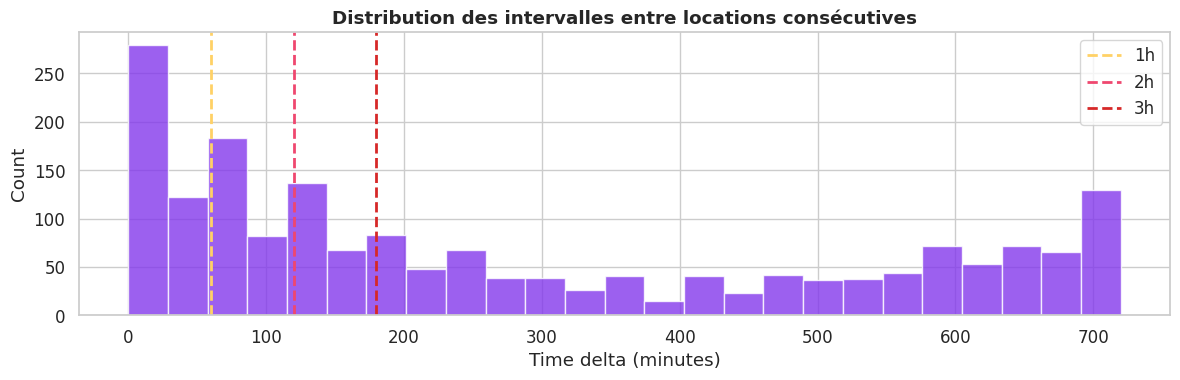

Time delta - mean: 279min, median: 180min
Valeurs uniques: [np.float64(0.0), np.float64(30.0), np.float64(60.0), np.float64(90.0), np.float64(120.0), np.float64(150.0), np.float64(180.0), np.float64(210.0), np.float64(240.0), np.float64(270.0), np.float64(300.0), np.float64(330.0), np.float64(360.0), np.float64(390.0), np.float64(420.0), np.float64(450.0), np.float64(480.0), np.float64(510.0), np.float64(540.0), np.float64(570.0), np.float64(600.0), np.float64(630.0), np.float64(660.0), np.float64(690.0), np.float64(720.0)]


In [15]:
fig, ax = plt.subplots(figsize=(12, 4))
td = consec['time_delta_with_previous_rental_in_minutes']
ax.hist(td, bins=25, color='#8338ec', alpha=0.8, edgecolor='white')
ax.set_xlabel('Time delta (minutes)')
ax.set_ylabel('Count')
ax.set_title('Distribution des intervalles entre locations consécutives', fontweight='bold')

# Marquer les seuils clés
for t, c, lbl in [(60, '#ffd166', '1h'), (120, '#ef476f', '2h'), (180, '#d62828', '3h')]:
    ax.axvline(t, color=c, linestyle='--', linewidth=2, label=lbl)
ax.legend()
plt.tight_layout()
plt.show()

print(f"Time delta - mean: {td.mean():.0f}min, median: {td.median():.0f}min")
print(f"Valeurs uniques: {sorted(td.unique())}")

### **5. Simulation de seuils & Dashboard KPIs**

#### **5.1 KPIs principaux**

| KPI | Valeur |
|-----|--------|
| Total locations | 21,310 |
| Taux de complétion | 84.7% |
| Taux de retard | 57.5% |
| Locations consécutives | 1,841 (8.6%) |
| Cas problématiques | 218 (11.8% des consec.) |
| Retard moyen | 59.7 min |
| Retard médian | 9 min |

#### **5.2 Fonction de simulation**

In [16]:
def simulate_threshold(data, thresholds):
    """
    Simule l'impact d'un délai minimum entre locations consécutives.
    
    Returns:
        DataFrame avec pour chaque seuil:
        - blocked: nombre de locations qui auraient été empêchées
        - solved: nombre de cas problématiques qui auraient été évités
        - efficiency_ratio: % solved / % blocked (plus c'est haut, mieux c'est)
    """
    n_consec = len(data)
    problematic = data[data['is_problematic']]
    n_problems = len(problematic)
    
    results = []
    for t in thresholds:
        blocked = (data['time_delta_with_previous_rental_in_minutes'] < t).sum()
        solved = (problematic['prev_delay'] <= 
                  problematic['time_delta_with_previous_rental_in_minutes'] + t).sum()
        
        pct_blocked = round(blocked / n_consec * 100, 1) if n_consec else 0
        pct_solved = round(solved / n_problems * 100, 1) if n_problems else 0
        efficiency = round(pct_solved / pct_blocked, 2) if pct_blocked > 0 else 0
        
        results.append({
            'threshold_min': t,
            'blocked': blocked,
            'pct_blocked': pct_blocked,
            'solved': solved,
            'n_problems': n_problems,
            'pct_solved': pct_solved,
            'efficiency_ratio': efficiency,
        })
    return pd.DataFrame(results)


In [19]:
# Simulation complète — 3 scopes
thresholds = list(range(0, 721, 30))

sim_all = simulate_threshold(consec, thresholds)
sim_connect = simulate_threshold(consec[consec['checkin_type'] == 'connect'], thresholds)
sim_mobile = simulate_threshold(consec[consec['checkin_type'] == 'mobile'], thresholds)

# Affichage des seuils clés
key_thresholds = [30, 60, 90, 120, 150, 180, 240, 360, 720]

print("SIMULATION - ALL CARS (n_consec=1841, n_problems=218)")
print(sim_all[sim_all['threshold_min'].isin(key_thresholds)].to_string(index=False))

print()
print("SIMULATION - CONNECT ONLY (n_consec=813, n_problems=69)")
print(sim_connect[sim_connect['threshold_min'].isin(key_thresholds)].to_string(index=False))

print()
print("SIMULATION - MOBILE ONLY (n_consec=1028, n_problems=149)")
print(sim_mobile[sim_mobile['threshold_min'].isin(key_thresholds)].to_string(index=False))

SIMULATION - ALL CARS (n_consec=1841, n_problems=218)
 threshold_min  blocked  pct_blocked  solved  n_problems  pct_solved  efficiency_ratio
            30      279        15.20     115         218       52.80              3.47
            60      401        21.80     152         218       69.70              3.20
            90      584        31.70     167         218       76.60              2.42
           120      666        36.20     177         218       81.20              2.24
           150      803        43.60     182         218       83.50              1.92
           180      870        47.30     194         218       89.00              1.88
           240     1001        54.40     198         218       90.80              1.67
           360     1170        63.60     205         218       94.00              1.48
           720     1711        92.90     209         218       95.90              1.03

SIMULATION - CONNECT ONLY (n_consec=813, n_problems=69)
 threshold_min  blo

#### **5.3 Visualisation du trade-off**

In [20]:
# Trade-off chart — 3 scopes côte à côte
fig = make_subplots(rows=1, cols=3,
                    subplot_titles=['All Cars (218 pb)', 'Connect Only (69 pb)', 'Mobile Only (149 pb)'],
                    shared_yaxes=True)

for i, (sim, label) in enumerate([(sim_all, 'All'), (sim_connect, 'Connect'), (sim_mobile, 'Mobile')]):
    col = i + 1
    sub = sim[sim['threshold_min'] > 0]
    
    fig.add_trace(go.Scatter(
        x=sub['threshold_min'], y=sub['pct_solved'],
        name='% Problèmes résolus', line=dict(color='#06d6a0', width=2.5, dash='dash'),
        showlegend=(col == 1)
    ), row=1, col=col)
    
    fig.add_trace(go.Scatter(
        x=sub['threshold_min'], y=sub['pct_blocked'],
        name='% Locations bloquées', line=dict(color='#ef476f', width=2.5),
        showlegend=(col == 1)
    ), row=1, col=col)
    
    # Sweet spot 120min
    fig.add_vline(x=120, line_dash='dot', line_color='#888', row=1, col=col)

fig.update_layout(height=400, title='Trade-off: Problèmes résolus vs Locations bloquées',
                  xaxis_title='Seuil (min)', yaxis_title='%')
fig.show()

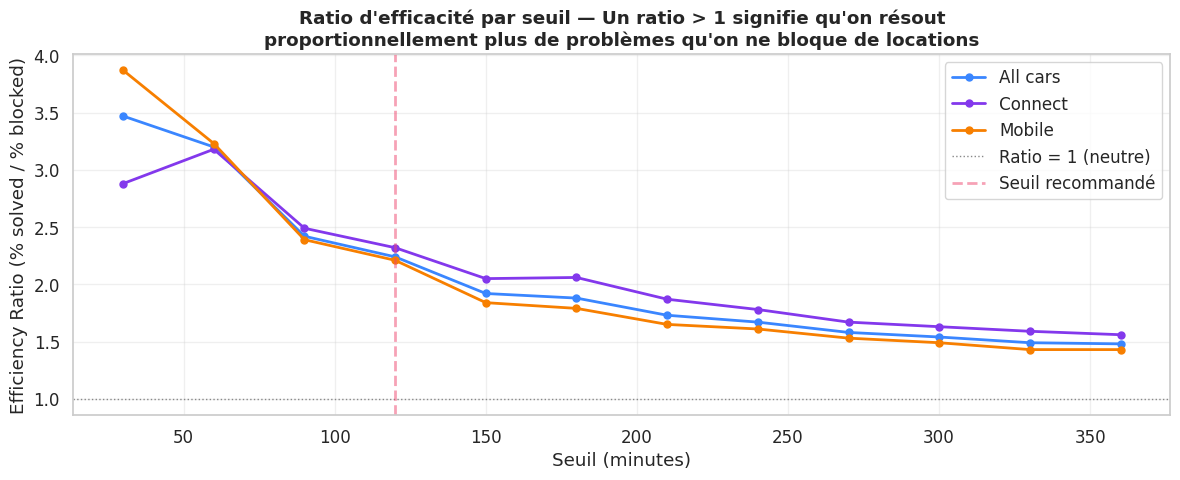

In [ ]:
# Efficiency ratio chart
fig, ax = plt.subplots(figsize=(12, 5))

for sim, label, color in [(sim_all, 'All cars', '#3a86ff'),
                           (sim_connect, 'Connect', '#8338ec'),
                           (sim_mobile, 'Mobile', '#f77f00')]:
    sub = sim[(sim['threshold_min'] > 0) & (sim['threshold_min'] <= 360)]
    ax.plot(sub['threshold_min'], sub['efficiency_ratio'], 'o-',
            color=color, linewidth=2, markersize=5, label=label)

ax.axhline(1, color='#888', linestyle=':', linewidth=1, label='Ratio = 1 (neutre)')
ax.axvline(120, color='#ef476f', linestyle='--', linewidth=2, alpha=0.5, label='Seuil recommandé')
ax.set_xlabel('Seuil (minutes)')
ax.set_ylabel('Efficiency Ratio (% solved / % blocked)')
ax.set_title('Ratio d\'efficacité par seuil - Un ratio > 1 signifie qu\'on résout\n'
             'proportionnellement plus de problèmes qu\'on ne bloque de locations', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3) 
plt.tight_layout()
plt.show()


### **6. Recommandation finale**

#### **Connect-only à 120 minutes (2 heures)**

| Métrique | All cars @ 120min | Connect @ 120min |
|----------|------------------|------------------|
| Problèmes résolus | 81.2% (177/218) | **84.1%** (58/69) |
| Locations bloquées | 36.2% (666/1841) | 36.3% (295/813) |
| Efficiency ratio | 2.24x | **2.32x** |

#### **Pourquoi Connect-only ?**

1. **Rendements décroissants** - 1h à 2h = +13pp solved. 2h à 3h = +10pp mais +10% blocked.
2. **Connect-first = safe** - 20% des locations, 44% des consécutives. Blast radius limité.
3. **Sans contact humain** - Sur Connect, le conducteur ne peut pas contacter le propriétaire.

#### **Rollout en 3 phases**

| Phase | Action | Durée |
|-------|--------|-------|
| Phase 1 | 2h delay sur Connect uniquement | 4-6 semaines |
| Phase 2 | Mesurer l'impact (cancel rate, CSAT, revenue) | 2-4 semaines |
| Phase 3 | Étendre au Mobile avec seuil ajusté (60-90min) | À déterminer |

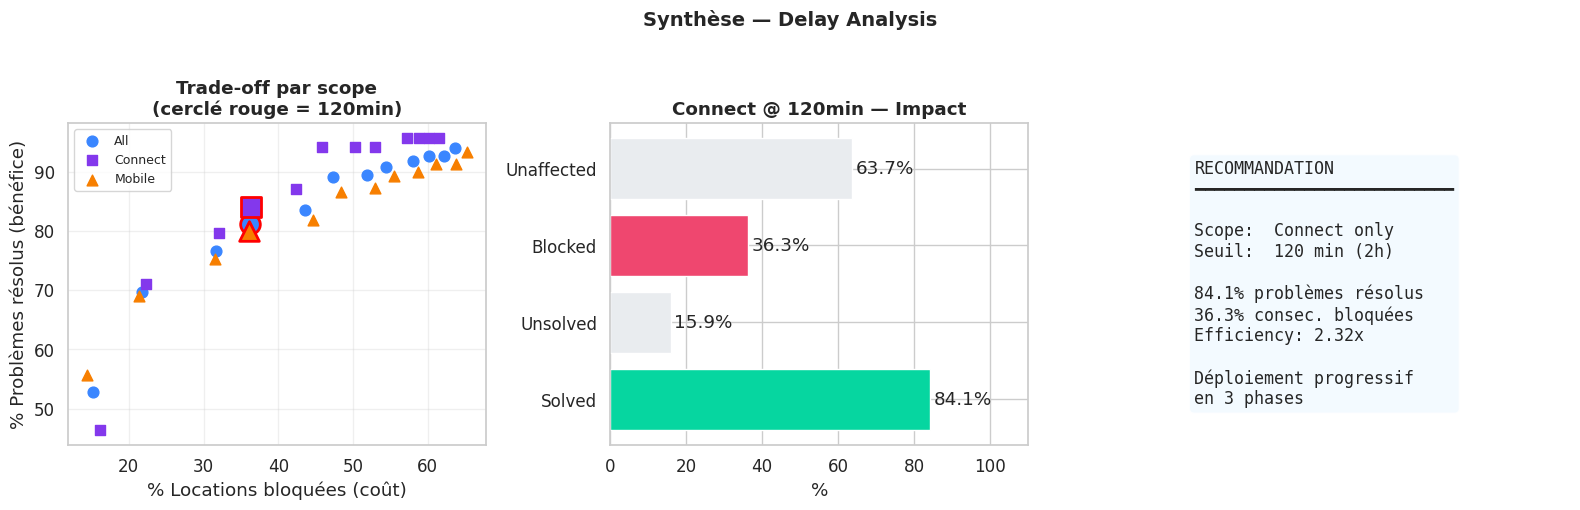

In [22]:
# Graphique de synthèse final
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Scatter: revenue risk vs problems solved
ax = axes[0]
for sim, label, color, marker in [(sim_all, 'All', '#3a86ff', 'o'),
                                   (sim_connect, 'Connect', '#8338ec', 's'),
                                   (sim_mobile, 'Mobile', '#f77f00', '^')]:
    sub = sim[(sim['threshold_min'] > 0) & (sim['threshold_min'] <= 360)]
    ax.scatter(sub['pct_blocked'], sub['pct_solved'], c=color, marker=marker, s=60, label=label)
    row_120 = sub[sub['threshold_min'] == 120].iloc[0]
    ax.scatter([row_120['pct_blocked']], [row_120['pct_solved']], c=color, marker=marker,
               s=200, edgecolors='red', linewidths=2, zorder=5)

ax.set_xlabel('% Locations bloquées (coût)')
ax.set_ylabel('% Problèmes résolus (bénéfice)')
ax.set_title('Trade-off par scope\n(cerclé rouge = 120min)', fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# 2. Bar: recommended threshold
ax = axes[1]
categories = ['Solved', 'Unsolved', 'Blocked', 'Unaffected']
values = [84.1, 15.9, 36.3, 63.7]
colors = ['#06d6a0', '#e9ecef', '#ef476f', '#e9ecef']
bars = ax.barh(categories, values, color=colors, edgecolor='white')
ax.set_xlabel('%')
ax.set_title('Connect @ 120min — Impact', fontweight='bold')
for bar, val in zip(bars, values):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, f'{val}%', va='center')
ax.set_xlim(0, 110)

# 3. Summary text
ax = axes[2]
ax.axis('off')
summary = (
    "RECOMMANDATION\n"
    "━━━━━━━━━━━━━━━━━━━━━━━━━━\n\n"
    "Scope:  Connect only\n"
    "Seuil:  120 min (2h)\n\n"
    "84.1% problèmes résolus\n"
    "36.3% consec. bloquées\n"
    "Efficiency: 2.32x\n\n"
    "Déploiement progressif\n"
    "en 3 phases"
)
ax.text(0.1, 0.5, summary, transform=ax.transAxes, fontsize=12,
        verticalalignment='center', fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='#f0f9ff', alpha=0.8))

plt.suptitle('Synthèse — Delay Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
